In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(r'D:\Python\ML\Data_Preprocessing\train.csv')
print(df.shape)
print(df.info())
print(df.describe())
print(df.head())
print(df.isnull().sum())

(891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842 

In [2]:

#Age
#So after running the code we can see age has 177 data missing which is about 20%
#so lets fill it with median
df['Age'].fillna(df['Age'].median(), inplace=True)
#Cabin
#Cabin column has 687 data missing out of 891 data which is lot so lets drop it
df.drop(columns=['Cabin'],inplace=True)
print(df.isnull().sum())
#Embarked
#Embarked has 2 data missing which is very less so lets fill that with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


C:\Users\USER\AppData\Local\Temp\ipykernel_14916\1067541795.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\USER\AppData\Local\Temp\ipykernel_14916\1067541795.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For ex

Text(0.5, 1.0, 'Fare')

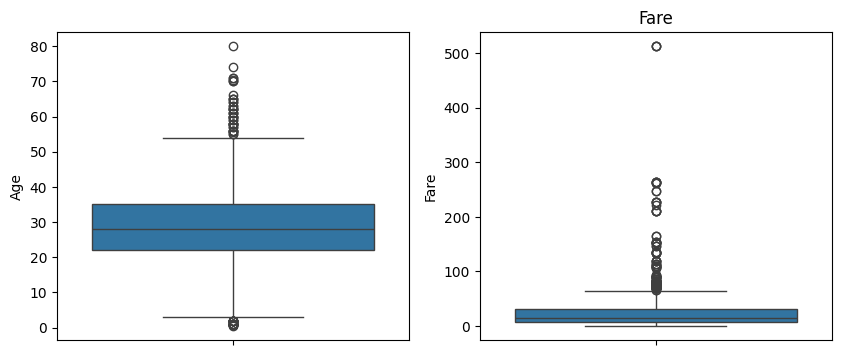

In [3]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.boxplot(df['Age'])
plt.subplot(1,2,2)
sns.boxplot(df['Fare'])
plt.title('Fare')

In [4]:
Q1=df['Fare'].quantile(0.25)
Q3=df['Fare'].quantile(0.75)
IQR=Q3-Q1
Lower=Q1-1.5*IQR
Higher=Q3+1.5*IQR
df['Fare']=df['Fare'].clip(Lower,Higher)
print(df['Fare'].describe())

count    891.000000
mean      24.046813
std       20.481625
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max       65.634400
Name: Fare, dtype: float64


In [5]:
print(df.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object


In [6]:
df.drop(columns=['Name','Ticket'],inplace=True)
df['Sex']=df['Sex'].map({'male':0,'female':1})
df=pd.get_dummies(df,columns=['Embarked'],drop_first=True)
print(df.head())
print(df.dtypes)

   PassengerId  Survived  Pclass  Sex   Age  SibSp  Parch     Fare  \
0            1         0       3    0  22.0      1      0   7.2500   
1            2         1       1    1  38.0      1      0  65.6344   
2            3         1       3    1  26.0      0      0   7.9250   
3            4         1       1    1  35.0      1      0  53.1000   
4            5         0       3    0  35.0      0      0   8.0500   

   Embarked_Q  Embarked_S  
0       False        True  
1       False       False  
2       False        True  
3       False        True  
4       False        True  
PassengerId      int64
Survived         int64
Pclass           int64
Sex              int64
Age            float64
SibSp            int64
Parch            int64
Fare           float64
Embarked_Q        bool
Embarked_S        bool
dtype: object


In [7]:
from sklearn.preprocessing import StandardScaler

In [8]:
scale_cols=['Age','Fare']
scaler=StandardScaler()
df[scale_cols]=scaler.fit_transform(df[scale_cols])
print(df.head())

   PassengerId  Survived  Pclass  Sex       Age  SibSp  Parch      Fare  \
0            1         0       3    0 -0.565736      1      0 -0.820552   
1            2         1       1    1  0.663861      1      0  2.031623   
2            3         1       3    1 -0.258337      0      0 -0.787578   
3            4         1       1    1  0.433312      1      0  1.419297   
4            5         0       3    0  0.433312      0      0 -0.781471   

   Embarked_Q  Embarked_S  
0       False        True  
1       False       False  
2       False        True  
3       False        True  
4       False        True  


In [9]:
df['Embarked_Q'] = df['Embarked_Q'].astype(int)
df['Embarked_S'] = df['Embarked_S'].astype(int)
df.drop(columns=['PassengerId'], inplace=True)
print(df.head())

   Survived  Pclass  Sex       Age  SibSp  Parch      Fare  Embarked_Q  \
0         0       3    0 -0.565736      1      0 -0.820552           0   
1         1       1    1  0.663861      1      0  2.031623           0   
2         1       3    1 -0.258337      0      0 -0.787578           0   
3         1       1    1  0.433312      1      0  1.419297           0   
4         0       3    0  0.433312      0      0 -0.781471           0   

   Embarked_S  
0           1  
1           0  
2           1  
3           1  
4           1  
